In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv("HI-Small_Trans.csv")

print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False))

print("\nDuplicate rows:")
print(df.duplicated().sum())

Shape: (5078345, 11)

Columns:
['Timestamp', 'From Bank', 'Account', 'To Bank', 'Account.1', 'Amount Received', 'Receiving Currency', 'Amount Paid', 'Payment Currency', 'Payment Format', 'Is Laundering']

First 5 rows:


,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,3697.34,US Dollar,3697.34,US Dollar,Reinvestment,0
1,2022/09/01 00:20,3208,8000F4580,1,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0
2,2022/09/01 00:00,3209,8000F4670,3209,8000F4670,14675.57,US Dollar,14675.57,US Dollar,Reinvestment,0
3,2022/09/01 00:02,12,8000F5030,12,8000F5030,2806.97,US Dollar,2806.97,US Dollar,Reinvestment,0
4,2022/09/01 00:06,10,8000F5200,10,8000F5200,36682.97,US Dollar,36682.97,US Dollar,Reinvestment,0



Data types:
Timestamp              object
From Bank               int64
Account                object
To Bank                 int64
Account.1              object
Amount Received       float64
Receiving Currency     object
Amount Paid           float64
Payment Currency       object
Payment Format         object
Is Laundering           int64
dtype: object

Missing values:
Timestamp             0
From Bank             0
Account               0
To Bank               0
Account.1             0
Amount Received       0
Receiving Currency    0
Amount Paid           0
Payment Currency      0
Payment Format        0
Is Laundering         0
dtype: int64

Duplicate rows:
9


In [4]:
print(df["Is Laundering"].value_counts())

print(
    df["Is Laundering"]
    .value_counts(normalize=True)
    .mul(100)
    .round(4)
)

Is Laundering
0    5073168
1       5177
Name: count, dtype: int64
Is Laundering
0    99.8981
1     0.1019
Name: proportion, dtype: float64


In [5]:
for col in [
    "Receiving Currency",
    "Payment Currency",
    "Payment Format"
]:
    print("\n", "=" * 50)
    print(col)
    print("Unique:", df[col].nunique())
    print(df[col].value_counts().head(20))


Receiving Currency
Unique: 15
Receiving Currency
US Dollar            1879341
Euro                 1172017
Swiss Franc           237884
Yuan                  206551
Shekel                194988
Rupee                 192065
UK Pound              181255
Ruble                 157361
Yen                   156319
Bitcoin               148151
Canadian Dollar       141357
Australian Dollar     138511
Mexican Peso          111030
Saudi Riyal            89971
Brazil Real            71544
Name: count, dtype: int64

Payment Currency
Unique: 15
Payment Currency
US Dollar            1895172
Euro                 1168297
Swiss Franc           234860
Yuan                  213752
Shekel                192184
Rupee                 190202
UK Pound              180738
Yen                   155209
Ruble                 155178
Bitcoin               146066
Canadian Dollar       140042
Australian Dollar     136769
Mexican Peso          110159
Saudi Riyal            89014
Brazil Real            70703
Name: co

In [6]:
print(
    df[
        ["Amount Received", "Amount Paid"]
    ].describe()
)

print("\nReceived amount percentiles:")
print(
    df["Amount Received"].quantile(
        [0.5, 0.9, 0.95, 0.99, 0.999]
    )
)

       Amount Received   Amount Paid
count     5.078345e+06  5.078345e+06
mean      5.988726e+06  4.509273e+06
std       1.037183e+09  8.697728e+08
min       1.000000e-06  1.000000e-06
25%       1.833700e+02  1.844800e+02
50%       1.411010e+03  1.414540e+03
75%       1.234627e+04  1.229784e+04
max       1.046302e+12  1.046302e+12

Received amount percentiles:
0.500    1.411010e+03
0.900    1.407368e+05
0.950    6.499065e+05
0.990    1.475123e+07
0.999    5.226685e+08
Name: Amount Received, dtype: float64


In [7]:
mismatch = (
    df["Receiving Currency"]
    != df["Payment Currency"]
)

print("Currency mismatches:", mismatch.sum())
print("Percentage:", mismatch.mean() * 100)

Currency mismatches: 72170
Percentage: 1.4211322783308342


In [8]:
import numpy as np
import pandas as pd

df_model = df.copy()

df_model["Timestamp"] = pd.to_datetime(
    df_model["Timestamp"]
)


df_model["Hour"] = df_model["Timestamp"].dt.hour
df_model["Day of Week"] = df_model["Timestamp"].dt.dayofweek
df_model["Day"] = df_model["Timestamp"].dt.day
df_model["Month"] = df_model["Timestamp"].dt.month

df_model["Is Weekend"] = (
    df_model["Day of Week"] >= 5
).astype("int8")




df_model["Log Amount Received"] = np.log1p(
    df_model["Amount Received"]
)

df_model["Log Amount Paid"] = np.log1p(
    df_model["Amount Paid"]
)

df_model["Amount Ratio"] = (
    df_model["Amount Received"] /
    (df_model["Amount Paid"] + 1e-9)
)



df_model["Currency Mismatch"] = (
    df_model["Receiving Currency"]
    != df_model["Payment Currency"]
).astype("int8")


print("New shape:", df_model.shape)

print("\nNew columns:")
print(df_model.columns.tolist())

New shape: (5078345, 20)

New columns:
['Timestamp', 'From Bank', 'Account', 'To Bank', 'Account.1', 'Amount Received', 'Receiving Currency', 'Amount Paid', 'Payment Currency', 'Payment Format', 'Is Laundering', 'Hour', 'Day of Week', 'Day', 'Month', 'Is Weekend', 'Log Amount Received', 'Log Amount Paid', 'Amount Ratio', 'Currency Mismatch']


In [9]:
print(
    df_model[
        [
            "Amount Received",
            "Amount Paid",
            "Log Amount Received",
            "Log Amount Paid",
            "Amount Ratio",
            "Currency Mismatch",
            "Hour",
            "Day of Week",
            "Month",
            "Is Weekend",
            "Is Laundering"
        ]
    ].head(10)
)

   Amount Received  Amount Paid  Log Amount Received  Log Amount Paid  \
0          3697.34      3697.34             8.215639         8.215639   
1             0.01         0.01             0.009950         0.009950   
2         14675.57     14675.57             9.594008         9.594008   
3          2806.97      2806.97             7.940217         7.940217   
4         36682.97     36682.97            10.510095        10.510095   
5          6162.44      6162.44             8.726390         8.726390   
6            14.26        14.26             2.725235         2.725235   
7            11.86        11.86             2.554122         2.554122   
8             7.66         7.66             2.158715         2.158715   
9           383.71       383.71             5.952490         5.952490   

   Amount Ratio  Currency Mismatch  Hour  Day of Week  Month  Is Weekend  \
0           1.0                  0     0            3      9           0   
1           1.0                  0     0    

In [10]:
print("NaN values:")
print(
    df_model.isna().sum()
    .sort_values(ascending=False)
    .head(20)
)

print("\nInfinite values:")
print(
    np.isinf(
        df_model.select_dtypes(include=np.number)
    ).sum().sort_values(ascending=False).head(20)
)

NaN values:
Timestamp              0
From Bank              0
Account                0
To Bank                0
Account.1              0
Amount Received        0
Receiving Currency     0
Amount Paid            0
Payment Currency       0
Payment Format         0
Is Laundering          0
Hour                   0
Day of Week            0
Day                    0
Month                  0
Is Weekend             0
Log Amount Received    0
Log Amount Paid        0
Amount Ratio           0
Currency Mismatch      0
dtype: int64

Infinite values:
From Bank              0
To Bank                0
Amount Received        0
Amount Paid            0
Is Laundering          0
Hour                   0
Day of Week            0
Day                    0
Month                  0
Is Weekend             0
Log Amount Received    0
Log Amount Paid        0
Amount Ratio           0
Currency Mismatch      0
dtype: int64


In [11]:
categorical_features = [
    "Receiving Currency",
    "Payment Currency",
    "Payment Format"
]

df_model = pd.get_dummies(
    df_model,
    columns=categorical_features,
    dtype="int8"
)

print("Shape after encoding:", df_model.shape)

Shape after encoding: (5078345, 54)


In [12]:
columns_to_drop = [
    "Is Laundering",
    "Timestamp",
    "Account",
    "Account.1",
    "From Bank",
    "To Bank"
]

X = df_model.drop(columns=columns_to_drop)
y = df_model["Is Laundering"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

X shape: (5078345, 48)
y shape: (5078345,)

Features:
['Amount Received', 'Amount Paid', 'Hour', 'Day of Week', 'Day', 'Month', 'Is Weekend', 'Log Amount Received', 'Log Amount Paid', 'Amount Ratio', 'Currency Mismatch', 'Receiving Currency_Australian Dollar', 'Receiving Currency_Bitcoin', 'Receiving Currency_Brazil Real', 'Receiving Currency_Canadian Dollar', 'Receiving Currency_Euro', 'Receiving Currency_Mexican Peso', 'Receiving Currency_Ruble', 'Receiving Currency_Rupee', 'Receiving Currency_Saudi Riyal', 'Receiving Currency_Shekel', 'Receiving Currency_Swiss Franc', 'Receiving Currency_UK Pound', 'Receiving Currency_US Dollar', 'Receiving Currency_Yen', 'Receiving Currency_Yuan', 'Payment Currency_Australian Dollar', 'Payment Currency_Bitcoin', 'Payment Currency_Brazil Real', 'Payment Currency_Canadian Dollar', 'Payment Currency_Euro', 'Payment Currency_Mexican Peso', 'Payment Currency_Ruble', 'Payment Currency_Rupee', 'Payment Currency_Saudi Riyal', 'Payment Currency_Shekel', 'Pa

In [13]:
print(X.dtypes.value_counts())

print("\nMissing values in X:")
print(X.isna().sum().sum())

print("\nInfinite values in X:")
print(
    np.isinf(X.select_dtypes(include=np.number)).sum().sum()
)

int8       39
float64     5
int32       4
Name: count, dtype: int64

Missing values in X:
0

Infinite values in X:
0


In [14]:
import sys

print("Python executable:")
print(sys.executable)

Python executable:
/usr/bin/python3


In [15]:
import sys
!{sys.executable} -m pip install scikit-learn

In [16]:
import sklearn

print("scikit-learn version:", sklearn.__version__)

scikit-learn version: 1.6.1


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTest class distribution:")
print(y_test.value_counts())

print("\nTraining percentages:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTest percentages:")
print(y_test.value_counts(normalize=True) * 100)

Training set: (4062676, 48)
Test set: (1015669, 48)

Training class distribution:
Is Laundering
0    4058534
1       4142
Name: count, dtype: int64

Test class distribution:
Is Laundering
0    1014634
1       1035
Name: count, dtype: int64

Training percentages:
Is Laundering
0    99.898047
1     0.101953
Name: proportion, dtype: float64

Test percentages:
Is Laundering
0    99.898097
1     0.101903
Name: proportion, dtype: float64


In [18]:
!pip install -q xgboost

In [19]:
import xgboost as xgb
from xgboost import XGBClassifier

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.4.0


In [20]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

In [21]:
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print("Legitimate transactions:", negative)
print("Laundering transactions:", positive)
print("Class imbalance ratio:", scale_pos_weight)

Legitimate transactions: 4058534
Laundering transactions: 4142
Class imbalance ratio: 979.8488652824723


In [22]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

print("Training XGBoost...")

xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost trained successfully.")

Training XGBoost...
XGBoost trained successfully.


In [23]:
y_pred_xgb = xgb_model.predict(X_test)

y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("Predictions generated.")

Predictions generated.


In [24]:
print("XGBoost Classification Report")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred_xgb,
        target_names=["Legitimate", "Laundering"],
        zero_division=0
    )
)

XGBoost Classification Report
              precision    recall  f1-score   support

  Legitimate       1.00      0.94      0.97   1014634
  Laundering       0.01      0.84      0.03      1035

    accuracy                           0.94   1015669
   macro avg       0.51      0.89      0.50   1015669
weighted avg       1.00      0.94      0.97   1015669



In [25]:
cm_xgb = confusion_matrix(
    y_test,
    y_pred_xgb
)

print("XGBoost Confusion Matrix")
print("=" * 60)
print(cm_xgb)

XGBoost Confusion Matrix
[[955132  59502]
 [   163    872]]


In [26]:
roc_auc_xgb = roc_auc_score(
    y_test,
    y_prob_xgb
)

print("XGBoost ROC-AUC:", roc_auc_xgb)

XGBoost ROC-AUC: 0.9334628276849722


In [27]:
pr_auc_xgb = average_precision_score(
    y_test,
    y_prob_xgb
)

print("XGBoost PR-AUC:", pr_auc_xgb)

XGBoost PR-AUC: 0.23137234218900143


In [28]:
xgb_precision = precision_score(
    y_test,
    y_pred_xgb,
    zero_division=0
)

xgb_recall = recall_score(
    y_test,
    y_pred_xgb,
    zero_division=0
)

xgb_f1 = f1_score(
    y_test,
    y_pred_xgb,
    zero_division=0
)

xgb_roc_auc = roc_auc_score(
    y_test,
    y_prob_xgb
)

xgb_pr_auc = average_precision_score(
    y_test,
    y_prob_xgb
)

print("XGBoost Results")
print("=" * 50)
print(f"Precision : {xgb_precision:.6f}")
print(f"Recall    : {xgb_recall:.6f}")
print(f"F1 Score  : {xgb_f1:.6f}")
print(f"ROC-AUC   : {xgb_roc_auc:.6f}")
print(f"PR-AUC    : {xgb_pr_auc:.6f}")

XGBoost Results
Precision : 0.014443
Recall    : 0.842512
F1 Score  : 0.028400
ROC-AUC   : 0.933463
PR-AUC    : 0.231372


In [50]:
comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "XGBoost"
    ],

    "Precision": [
        precision_score(
            y_test,
            y_pred_basic,
            zero_division=0
        ),
        xgb_precision
    ],

    "Recall": [
        recall_score(
            y_test,
            y_pred_basic,
            zero_division=0
        ),
        xgb_recall
    ],

    "F1": [
        f1_score(
            y_test,
            y_pred_basic,
            zero_division=0
        ),
        xgb_f1
    ],

    "ROC-AUC": [
        roc_auc_score(
            y_test,
            y_prob_basic
        ),
        xgb_roc_auc
    ],

    "PR-AUC": [
        average_precision_score(
            y_test,
            y_prob_basic
        ),
        xgb_pr_auc
    ]
})

display(comparison)

,Model,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Decision Tree,0.925466,0.143961,0.249164,0.920153,0.157530
1,XGBoost,0.014443,0.842512,0.028400,0.933463,0.231372


In [52]:
comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "XGBoost"
    ],

    "Precision": [
        precision_score(y_test, y_pred_basic, zero_division=0),
        xgb_precision
    ],

    "Recall": [
        recall_score(y_test, y_pred_basic, zero_division=0),
        xgb_recall
    ],

    "F1": [
        f1_score(y_test, y_pred_basic, zero_division=0),
        xgb_f1
    ],

    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_basic),
        xgb_roc_auc
    ],

    "PR-AUC": [
        average_precision_score(y_test, y_prob_basic),
        xgb_pr_auc
    ]
})

display(comparison)

,Model,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Decision Tree,0.925466,0.143961,0.249164,0.920153,0.157530
1,XGBoost,0.014443,0.842512,0.028400,0.933463,0.231372


In [30]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report

dummy = DummyClassifier(
    strategy="most_frequent"
)

dummy.fit(X_train, y_train)

dummy_pred = dummy.predict(X_test)

print(classification_report(
    y_test,
    dummy_pred,
    zero_division=0
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1014634
           1       0.00      0.00      0.00      1035

    accuracy                           1.00   1015669
   macro avg       0.50      0.50      0.50   1015669
weighted avg       1.00      1.00      1.00   1015669



In [31]:
from sklearn.tree import DecisionTreeClassifier

dt_basic = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt_basic.fit(X_train, y_train)

print("Decision Tree trained.")

Decision Tree trained.


In [32]:
y_pred_basic = dt_basic.predict(X_test)

y_prob_basic = dt_basic.predict_proba(X_test)[:, 1]

In [33]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score
)

print("Classification Report")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred_basic,
        target_names=["Legitimate", "Laundering"],
        zero_division=0
    )
)

print("\nConfusion Matrix")
print("=" * 60)

cm = confusion_matrix(
    y_test,
    y_pred_basic
)

print(cm)

print("\nROC-AUC:")
print(roc_auc_score(y_test, y_prob_basic))

print("\nPR-AUC:")
print(average_precision_score(y_test, y_prob_basic))

Classification Report
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00   1014634
  Laundering       0.93      0.14      0.25      1035

    accuracy                           1.00   1015669
   macro avg       0.96      0.57      0.62   1015669
weighted avg       1.00      1.00      1.00   1015669


Confusion Matrix
[[1014622      12]
 [    886     149]]

ROC-AUC:
0.9201527394009781

PR-AUC:
0.15753027374671613


In [34]:
dt_balanced = DecisionTreeClassifier(
    max_depth=5,
    class_weight="balanced",
    random_state=42
)

dt_balanced.fit(X_train, y_train)

print("Balanced Decision Tree trained.")

Balanced Decision Tree trained.


In [35]:
y_pred_balanced = dt_balanced.predict(X_test)

y_prob_balanced = (
    dt_balanced.predict_proba(X_test)[:, 1]
)

In [36]:
print(
    classification_report(
        y_test,
        y_pred_balanced,
        target_names=["Legitimate", "Laundering"],
        zero_division=0
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred_balanced
    )
)

print(
    "\nROC-AUC:",
    roc_auc_score(
        y_test,
        y_prob_balanced
    )
)

print(
    "PR-AUC:",
    average_precision_score(
        y_test,
        y_prob_balanced
    )
)

              precision    recall  f1-score   support

  Legitimate       1.00      0.92      0.96   1014634
  Laundering       0.01      0.88      0.02      1035

    accuracy                           0.92   1015669
   macro avg       0.51      0.90      0.49   1015669
weighted avg       1.00      0.92      0.96   1015669


Confusion Matrix:
[[929812  84822]
 [   126    909]]

ROC-AUC: 0.9202712648036175
PR-AUC: 0.0153540127985397


In [53]:
comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Balanced Decision Tree",
        "XGBoost"
    ],

    "Precision": [
        precision_score(y_test, y_pred_basic, zero_division=0),
        precision_score(y_test, y_pred_balanced, zero_division=0),
        xgb_precision
    ],

    "Recall": [
        recall_score(y_test, y_pred_basic, zero_division=0),
        recall_score(y_test, y_pred_balanced, zero_division=0),
        xgb_recall
    ],

    "F1": [
        f1_score(y_test, y_pred_basic, zero_division=0),
        f1_score(y_test, y_pred_balanced, zero_division=0),
        xgb_f1
    ],

    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_basic),
        roc_auc_score(y_test, y_prob_balanced),
        xgb_roc_auc
    ],

    "PR-AUC": [
        average_precision_score(y_test, y_prob_basic),
        average_precision_score(y_test, y_prob_balanced),
        xgb_pr_auc
    ]
})

display(comparison)

,Model,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Decision Tree,0.925466,0.143961,0.249164,0.920153,0.157530
1,Balanced Decision Tree,0.010603,0.878261,0.020953,0.920271,0.015354
2,XGBoost,0.014443,0.842512,0.028400,0.933463,0.231372


In [54]:
thresholds = [
    0.50,
    0.40,
    0.30,
    0.20,
    0.10,
    0.05,
    0.02,
    0.01
]

xgb_threshold_results = []

for threshold in thresholds:

    y_pred_threshold = (
        y_prob_xgb >= threshold
    ).astype(int)

    xgb_threshold_results.append({
        "Threshold": threshold,

        "Precision": precision_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),

        "Recall": recall_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),

        "F1": f1_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        )
    })

xgb_threshold_df = pd.DataFrame(
    xgb_threshold_results
)

display(xgb_threshold_df)

,Threshold,Precision,Recall,F1
0,0.50,0.014443,0.842512,0.028400
1,0.40,0.012354,0.853140,0.024355
2,0.30,0.009821,0.863768,0.019421
3,0.20,0.006400,0.880193,0.012708
4,0.10,0.002917,0.918841,0.005816
5,0.05,0.001791,0.961353,0.003576
6,0.02,0.001367,0.989372,0.002730
7,0.01,0.001265,0.998068,0.002527


In [55]:
best_threshold_row = xgb_threshold_df.loc[
    xgb_threshold_df["F1"].idxmax()
]

print("Best XGBoost threshold based on F1:")
print(best_threshold_row)

Best XGBoost threshold based on F1:
Threshold    0.500000
Precision    0.014443
Recall       0.842512
F1           0.028400
Name: 0, dtype: float64


In [56]:
importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("Top 20 XGBoost Features")
print("=" * 50)

display(
    importance.head(20).to_frame("Importance")
)

Top 20 XGBoost Features


,Importance
Payment Format_Reinvestment,0.209683
Payment Format_ACH,0.103033
Payment Format_Wire,0.077695
Payment Format_Credit Card,0.071246
Currency Mismatch,0.058571
Payment Format_Cheque,0.054597
Payment Format_Cash,0.039892
Amount Received,0.018737
Payment Format_Bitcoin,0.015631
Amount Ratio,0.014508


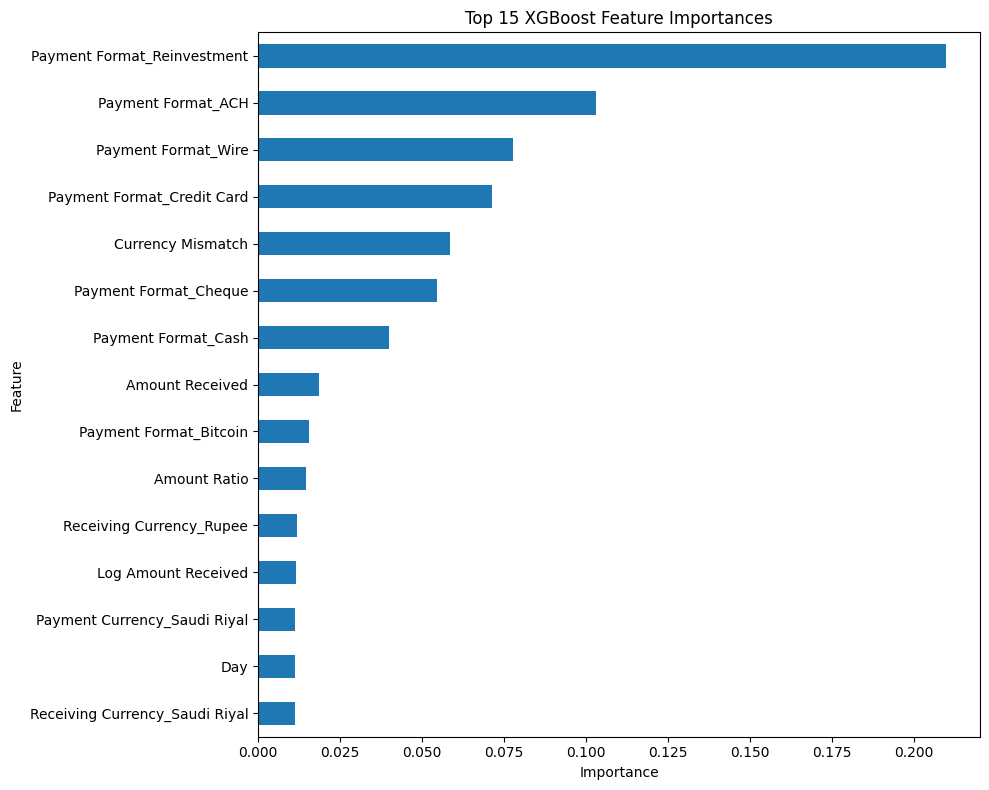

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

importance.head(15).sort_values().plot(
    kind="barh"
)

plt.title("Top 15 XGBoost Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [40]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

thresholds = [
    0.50,
    0.40,
    0.30,
    0.20,
    0.10,
    0.05,
    0.02,
    0.01
]

threshold_results = []

for threshold in thresholds:

    y_pred_threshold = (
        y_prob_basic >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(threshold_results)

display(threshold_df)

,Threshold,Precision,Recall,F1
0,0.50,0.925466,0.143961,0.249164
1,0.40,0.925466,0.143961,0.249164
2,0.30,0.925466,0.143961,0.249164
3,0.20,0.925466,0.143961,0.249164
4,0.10,0.925466,0.143961,0.249164
5,0.05,0.228571,0.177778,0.200000
6,0.02,0.228571,0.177778,0.200000
7,0.01,0.017962,0.657005,0.034968


In [41]:
importance = pd.Series(
    dt_basic.feature_importances_,
    index=X_train.columns
).sort_values(
    ascending=False
)

print(importance.head(20))

Day                                   0.564532
Currency Mismatch                     0.326451
Payment Format_ACH                    0.031855
Log Amount Received                   0.030943
Amount Paid                           0.018949
Payment Currency_Saudi Riyal          0.012654
Amount Received                       0.010548
Is Weekend                            0.002578
Hour                                  0.001450
Payment Format_Reinvestment           0.000021
Payment Currency_Bitcoin              0.000012
Payment Format_Wire                   0.000008
Month                                 0.000000
Log Amount Paid                       0.000000
Amount Ratio                          0.000000
Day of Week                           0.000000
Receiving Currency_Euro               0.000000
Receiving Currency_Canadian Dollar    0.000000
Receiving Currency_Brazil Real        0.000000
Receiving Currency_Bitcoin            0.000000
dtype: float64


In [42]:
import sys
!{sys.executable} -m pip install matplotlib

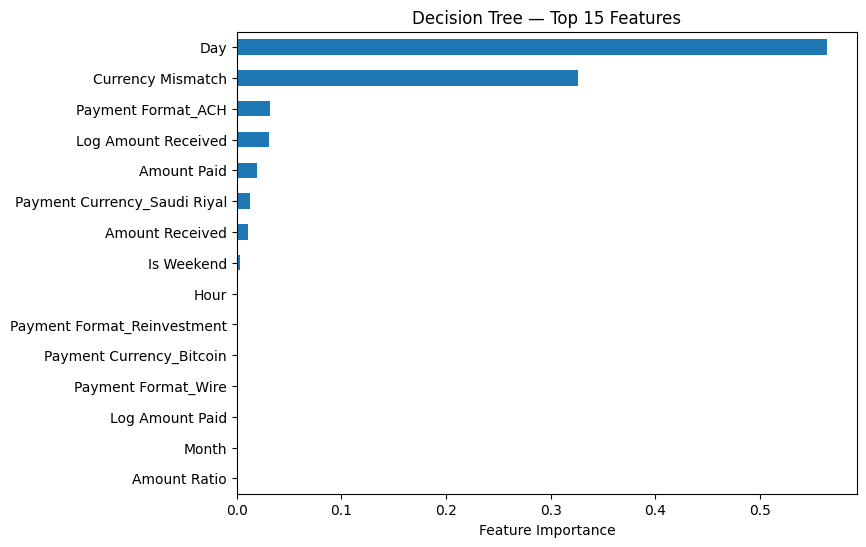

In [43]:
import matplotlib.pyplot as plt

importance.head(15).sort_values().plot(
    kind="barh",
    figsize=(8, 6)
)

plt.title("Decision Tree — Top 15 Features")
plt.xlabel("Feature Importance")
plt.show()

In [44]:
day_analysis = (
    df.groupby("Day" if "Day" in df.columns else "Timestamp")
)

In [45]:
day_analysis = (
    df_model
    .groupby("Day")["Is Laundering"]
    .agg(
        Transactions="count",
        Laundering="sum",
        Laundering_Rate="mean"
    )
)

day_analysis["Laundering_Rate"] *= 100

display(day_analysis)

,Transactions,Laundering,Laundering_Rate
Day,,,
1,1114921,322,0.028881
2,754449,408,0.054079
3,207382,391,0.188541
4,207430,407,0.196211
5,482650,471,0.097586
6,482089,531,0.110146
7,482751,497,0.102952
8,482773,539,0.111647
9,654467,514,0.078537


In [46]:
import sys

print("Python executable:")
print(sys.executable)

Python executable:
/usr/bin/python3


In [47]:
currency_analysis = (
    df_model
    .groupby("Currency Mismatch")["Is Laundering"]
    .agg(
        Transactions="count",
        Laundering="sum",
        Laundering_Rate="mean"
    )
)

currency_analysis["Laundering_Rate"] *= 100

display(currency_analysis)

,Transactions,Laundering,Laundering_Rate
Currency Mismatch,,,
0,5006175,5177,0.103412
1,72170,0,0.000000


In [48]:
ach_analysis = (
    df_model
    .groupby("Payment Format_ACH")["Is Laundering"]
    .agg(
        Transactions="count",
        Laundering="sum",
        Laundering_Rate="mean"
    )
)

ach_analysis["Laundering_Rate"] *= 100

display(ach_analysis)

,Transactions,Laundering,Laundering_Rate
Payment Format_ACH,,,
0,4477548,694,0.015500
1,600797,4483,0.746175


In [49]:
print("Minimum timestamp:", df_model["Timestamp"].min())
print("Maximum timestamp:", df_model["Timestamp"].max())

monthly_analysis = (
    df_model
    .assign(Month_Date=df_model["Timestamp"].dt.to_period("M"))
    .groupby("Month_Date")["Is Laundering"]
    .agg(
        Transactions="count",
        Laundering="sum",
        Laundering_Rate="mean"
    )
)

monthly_analysis["Laundering_Rate"] *= 100

display(monthly_analysis)

Minimum timestamp: 2022-09-01 00:00:00
Maximum timestamp: 2022-09-18 16:18:00


,Transactions,Laundering,Laundering_Rate
Month_Date,,,
2022-09,5078345,5177,0.101943
